# Chapter 13. Optimization

## The basics of gradient descent

### Implementing gradient descent

In [10]:
class Function:
    def __init__(self):
        pass
    
    def __call__(self, *args, **kwargs):
        pass
    
    def prime(self):
        pass
    
    def parameters(self):
        return dict()

This code implements the classic gradient descent optimization algorithm, which is fundamental to machine learning and neural network training. The function takes a mathematical function `f` (which must have a `prime()` method for computing derivatives), an initial starting point `x_init`, and several hyperparameters that control the optimization process.

The algorithm works by iteratively moving in the direction opposite to the gradient (slope) of the function. Starting from `x_init`, it computes the gradient at the current point using `f.prime(x)`, then takes a step in the negative gradient direction by computing `x_next = x - learning_rate * grad`. The `learning_rate` parameter controls how big these steps are - too large and the algorithm might overshoot the minimum, too small and it will converge very slowly.

The function stores all intermediate values in the `xs` list, which starts with the initial guess and grows by one element each iteration. This tracking is useful for visualization and debugging purposes. The loop runs for `n_iter` iterations, and depending on the `return_all` flag, the function either returns just the final optimized value or the complete trajectory of all intermediate points.

One important detail is that this implementation assumes the function `f` has a `prime()` method that can compute the derivative analytically. This is a simplified version compared to modern deep learning frameworks that use automatic differentiation, but it clearly illustrates the core concept of gradient descent optimization.

In [11]:
''''
    Gradient Descent Optimization
    This function performs gradient descent optimization on a given function f.
'''
def gradient_descent(
    f: Function,  
    x_init: float,                  # the initial guess
    learning_rate: float = 0.1,     # the learning rate
    n_iter: int = 1000,             # number of steps
    return_all: bool = False        # if true, returns all intermediate values
):
    xs = [x_init]    # we store the intermediate results for visualization

    for n in range(n_iter): # iterate for a fixed number of steps
        x = xs[-1] # the last value in the list
        grad = f.prime(x) # compute the gradient at the current point
        x_next = x - learning_rate*grad # update the current point
        xs.append(x_next) # store the intermediate result

    if return_all:
        return xs
    else:
        return x

The key reason for using **subtraction** (`x - learning_rate*grad`) instead of **addition** (`x + learning_rate*grad`) lies in the fundamental goal of optimization: **finding the minimum** of a function.

## Understanding the Gradient Direction

The gradient `grad = f.prime(x)` tells us the direction of **steepest ascent** at point `x`. In other words:
- If the gradient is **positive**, the function is increasing as we move to the right
- If the gradient is **negative**, the function is decreasing as we move to the right

## Why We Want to Go Against the Gradient

Since we're trying to **minimize** the function (find the lowest point), we want to move in the direction that **decreases** the function value. This means we need to move in the **opposite direction** of the gradient.

## Concrete Example

Consider the simple quadratic function `f(x) = x²`:
- At `x = 5`, the gradient is `f'(5) = 2*5 = 10` (positive)
- This tells us the function is increasing steeply to the right
- To reach the minimum at `x = 0`, we need to move **left** (negative direction)
- So we compute: `x_next = 5 - learning_rate * 10`, which moves us leftward toward 0

If we used addition instead:
- `x_next = 5 + learning_rate * 10` would move us further away from the minimum
- We'd be climbing **uphill** instead of going **downhill**

## The Mathematical Intuition

The update rule `x_next = x - learning_rate * grad` implements the principle:
- **Move in the direction opposite to the gradient**
- **Take steps proportional to the steepness** (larger gradients = bigger steps)
- **Scale the step size** with the learning rate

This ensures we consistently move toward lower function values, which is exactly what we want in optimization.

In [3]:
class Square(Function):
    def __call__(self, x):
        return x**2
    
    def prime(self, x):
        return 2*x

In [4]:
f = Square()

gradient_descent(f, x_init=5.0)

7.688949513507002e-97

In [5]:
import numpy as np
import matplotlib.pyplot as plt


def plot_gradient_descent(f, xs: list, x_min: float, x_max: float, label: str = "f(x)"):
    ys = [f(x) for x in xs]

    grid = np.linspace(x_min, x_max, 1000)
    fs = [f(x) for x in grid]

    with plt.style.context("seaborn-v0_8-whitegrid"):
        plt.figure(figsize=(8, 8))
        plt.plot(grid, fs, label=label, c="b", lw=2.0)
        plt.plot(xs, ys, label="gradient descent", c="r", lw=4.0)
        plt.scatter(xs, ys, c="r", s=100.0)
        plt.legend()
        plt.show()

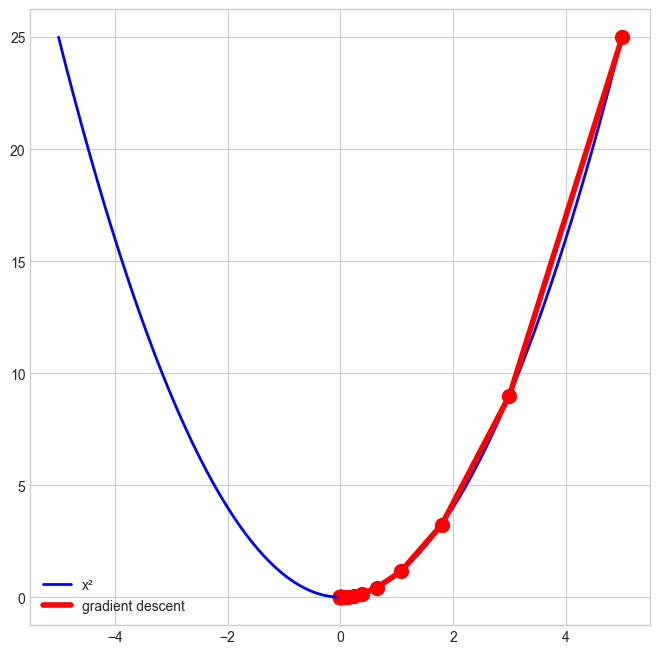

In [6]:
xs = gradient_descent(f, x_init=5.0, n_iter=25, learning_rate=0.2, return_all=True)
plot_gradient_descent(f, xs, x_min=-5, x_max=5, label="x²")

### Drawbacks and caveats

In [7]:
class CosPlusSquare(Function):
    def __call__(self, x):
        return np.sin(x) + 0.5*x
    
    def prime(self, x):
        return np.cos(x) + 0.5

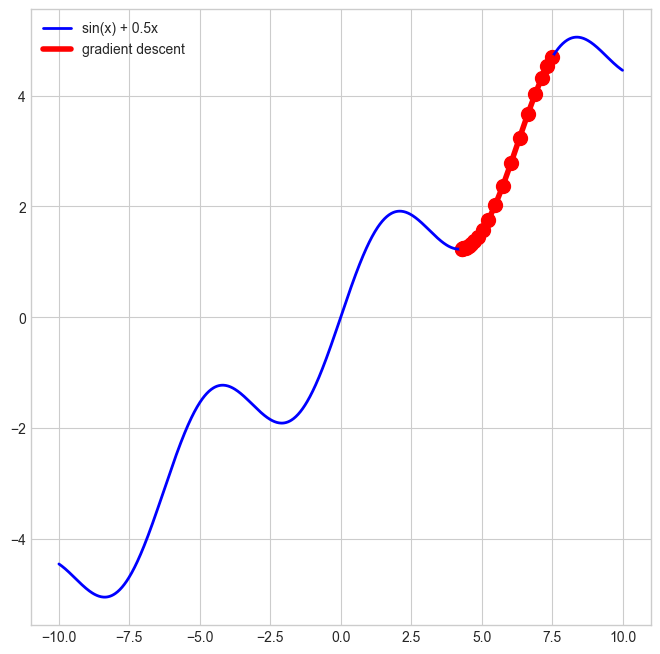

In [8]:
f = CosPlusSquare()

xs = gradient_descent(f, x_init=7.5, n_iter=20, learning_rate=0.2, return_all=True)
plot_gradient_descent(f, xs, -10, 10, label="sin(x) + 0.5x")

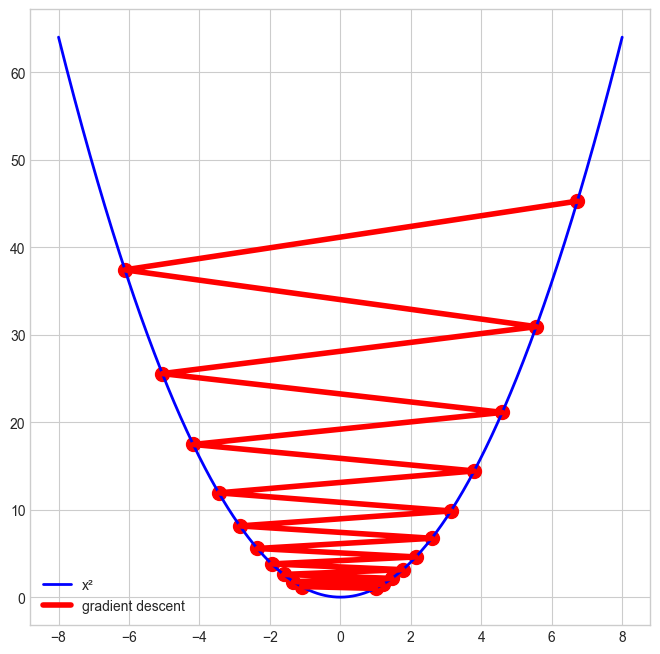

In [9]:
f = Square()

xs = gradient_descent(f, x_init=1.0, n_iter=20, learning_rate=1.05, return_all=True)
plot_gradient_descent(f, xs, -8, 8, label="x²")